# Student Marks Prediction
---

## Data Cleaning and EDA
---

In [61]:
# importing the required libraries  
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
# reading the dataset
df = pd.read_csv('..\\datasets\\student-performance.xls')
pd.set_option('display.max_columns',None)
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher   
1     GP   F   17       U     GT3       T     1     1  at_home     other   
2     GP   F   15       U     LE3       T     1     1  at_home     other   
3     GP   F   15       U     GT3       T     4     2   health  services   
4     GP   F   16       U     GT3       T     3     3    other     other   

   reason guardian  traveltime  studytime  failures schoolsup famsup paid  \
0  course   mother           2          2         0       yes     no   no   
1  course   father           1          2         0        no    yes   no   
2   other   mother           1          2         0       yes     no   no   
3    home   mother           1          3         0        no    yes   no   
4    home   father           1          2         0        no    yes   no   

  activities nursery higher internet romantic  famrel  freetime  goout  Dalc  \


In [63]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')


#### Statistical summary of the dataset:
---

In [64]:
print("Description of the dataset (numeric):")
pd.set_option('display.float_format', '{:,.2f}'.format)
print(df.describe())


Description of the dataset (numeric):
         age   Medu   Fedu  traveltime  studytime  failures  famrel  freetime  \
count 649.00 649.00 649.00      649.00     649.00    649.00  649.00    649.00   
mean   16.74   2.51   2.31        1.57       1.93      0.22    3.93      3.18   
std     1.22   1.13   1.10        0.75       0.83      0.59    0.96      1.05   
min    15.00   0.00   0.00        1.00       1.00      0.00    1.00      1.00   
25%    16.00   2.00   1.00        1.00       1.00      0.00    4.00      3.00   
50%    17.00   2.00   2.00        1.00       2.00      0.00    4.00      3.00   
75%    18.00   4.00   3.00        2.00       2.00      0.00    5.00      4.00   
max    22.00   4.00   4.00        4.00       4.00      3.00    5.00      5.00   

       goout   Dalc   Walc  health  absences     G1     G2     G3  
count 649.00 649.00 649.00  649.00    649.00 649.00 649.00 649.00  
mean    3.18   1.50   2.28    3.54      3.66  11.40  11.57  11.91  
std     1.18   0.92   1.28  

In [65]:
print("\nDescription of the dataset (categorical):")
print(df.describe(include='str'))


Description of the dataset (categorical):
       school  sex address famsize Pstatus   Mjob   Fjob  reason guardian  \
count     649  649     649     649     649    649    649     649      649   
unique      2    2       2       2       2      5      5       4        3   
top        GP    F       U     GT3       T  other  other  course   mother   
freq      423  383     452     457     569    258    367     285      455   

       schoolsup famsup paid activities nursery higher internet romantic  
count        649    649  649        649     649    649      649      649  
unique         2      2    2          2       2      2        2        2  
top           no    yes   no         no     yes    yes      yes       no  
freq         581    398  610        334     521    580      498      410  


In [66]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-n

In [67]:
print("\nNumber of missing values in each column:")
print(df.isnull().sum())


Number of missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [68]:
# checking the duplicates rows
print(df.duplicated().sum())

0


---


In [69]:
# converting the str values of columns containing yes and no values to binary values 
binary_columns = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic']

map_dict = {
    'sex': {'F': 1, 'M': 0},
    'school': {'GP': 1, 'MS': 0},
    'address': {'U': 1, 'R': 0},
    'famsize': {'GT3': 1, 'LE3': 0},
    'Pstatus': {'T': 1, 'A': 0}
}

col = list(map_dict.keys())

# This converts data into binary
df[col] = df[col].replace(map_dict)
df[binary_columns] = df[binary_columns].replace({'yes': 1, 'no': 0})

In [70]:
# performing the One-Hot Encoding to break the column into separate binary flag columns.
df = pd.get_dummies(df, columns=["guardian","Mjob", "Fjob", "reason"],dtype= int)
df = df.drop(columns='guardian_other')

In [71]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,guardian_father,guardian_mother,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation
0,1,1,18,1,1,0,4,4,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,4,0,11,11,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0
1,1,1,17,1,1,1,1,1,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,2,9,11,11,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0
2,1,1,15,1,0,1,1,1,1,2,0,1,0,0,0,1,1,1,0,4,3,2,2,3,3,6,12,13,12,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0
3,1,1,15,1,1,1,4,2,1,3,0,0,1,0,1,1,1,1,1,3,2,2,1,1,5,0,14,14,14,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0
4,1,1,16,1,1,1,3,3,1,2,0,0,1,0,0,1,1,0,0,4,3,2,1,2,5,0,11,13,13,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0


In [72]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,guardian_father,guardian_mother,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation
644,0,1,19,0,1,1,2,3,1,3,1,0,0,0,1,0,1,1,0,5,4,2,1,2,5,4,10,11,10,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0
645,0,1,18,1,0,1,3,1,1,2,0,0,1,0,0,1,1,1,0,4,3,4,1,1,1,4,15,15,16,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0
646,0,1,18,1,1,1,1,1,2,2,0,0,0,0,1,1,1,0,0,1,1,1,1,1,5,6,11,12,9,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0
647,0,0,17,1,0,1,3,1,2,1,0,0,0,0,0,0,1,1,0,2,4,5,3,4,2,6,10,10,10,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0
648,0,0,18,0,0,1,3,2,3,1,0,0,0,0,0,0,1,1,0,4,4,1,3,4,5,4,10,11,11,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0


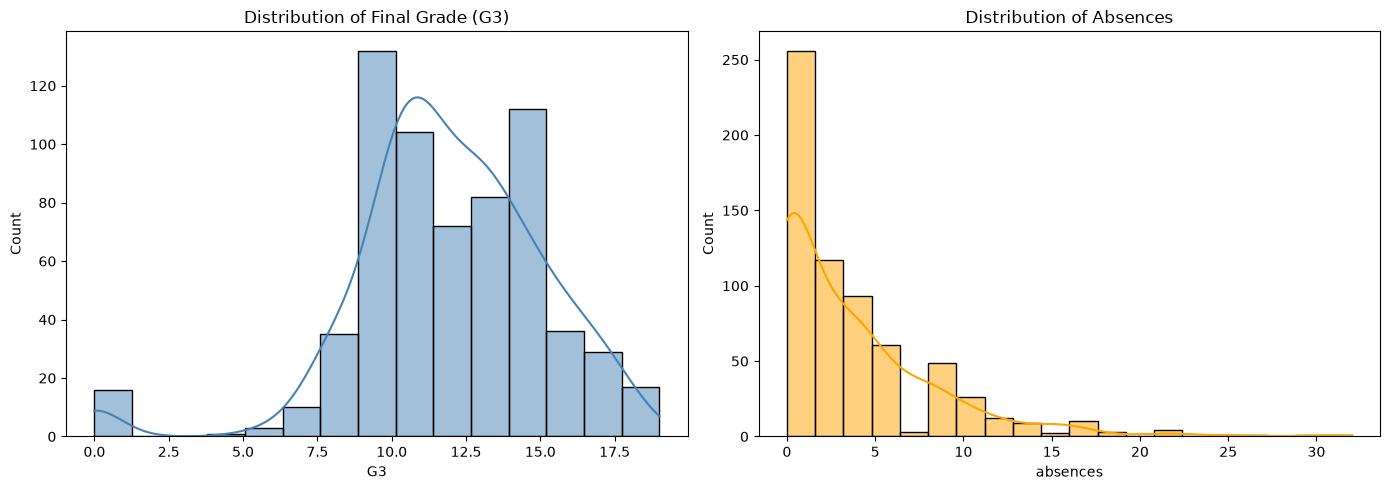

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df["G3"], bins=15, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribution of Final Grade (G3)")

sns.histplot(df["absences"], bins=20, kde=True, ax=ax[1], color="orange")
ax[1].set_title("Distribution of Absences")

plt.tight_layout()
plt.show()

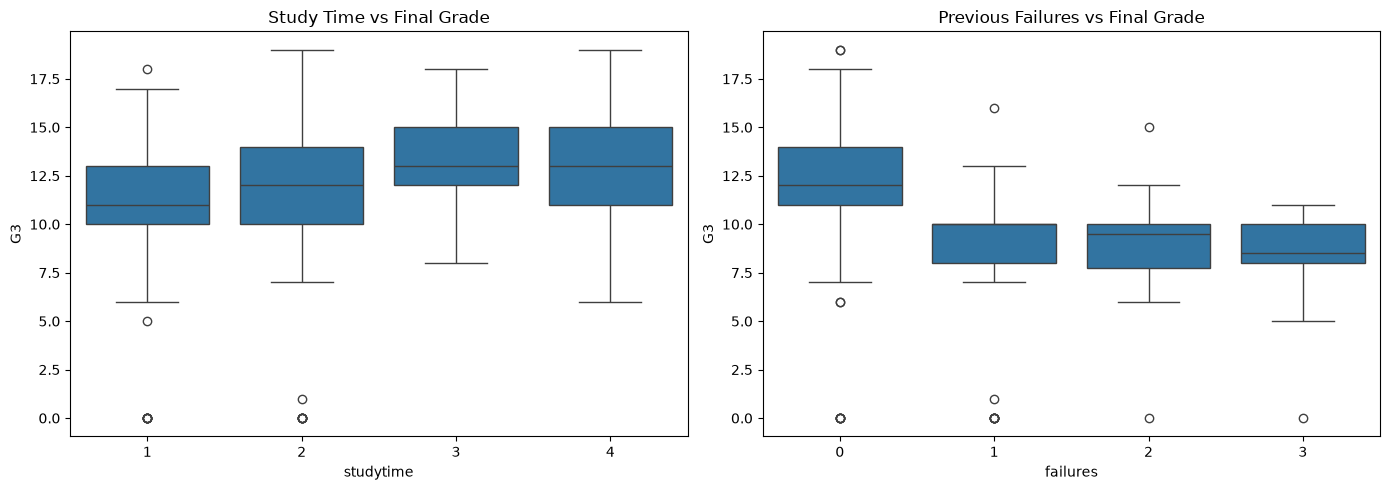

In [74]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(x="studytime", y="G3", data=df, ax=ax[0])
ax[0].set_title("Study Time vs Final Grade")

sns.boxplot(x="failures", y="G3", data=df, ax=ax[1])
ax[1].set_title("Previous Failures vs Final Grade")

plt.tight_layout()
plt.show()

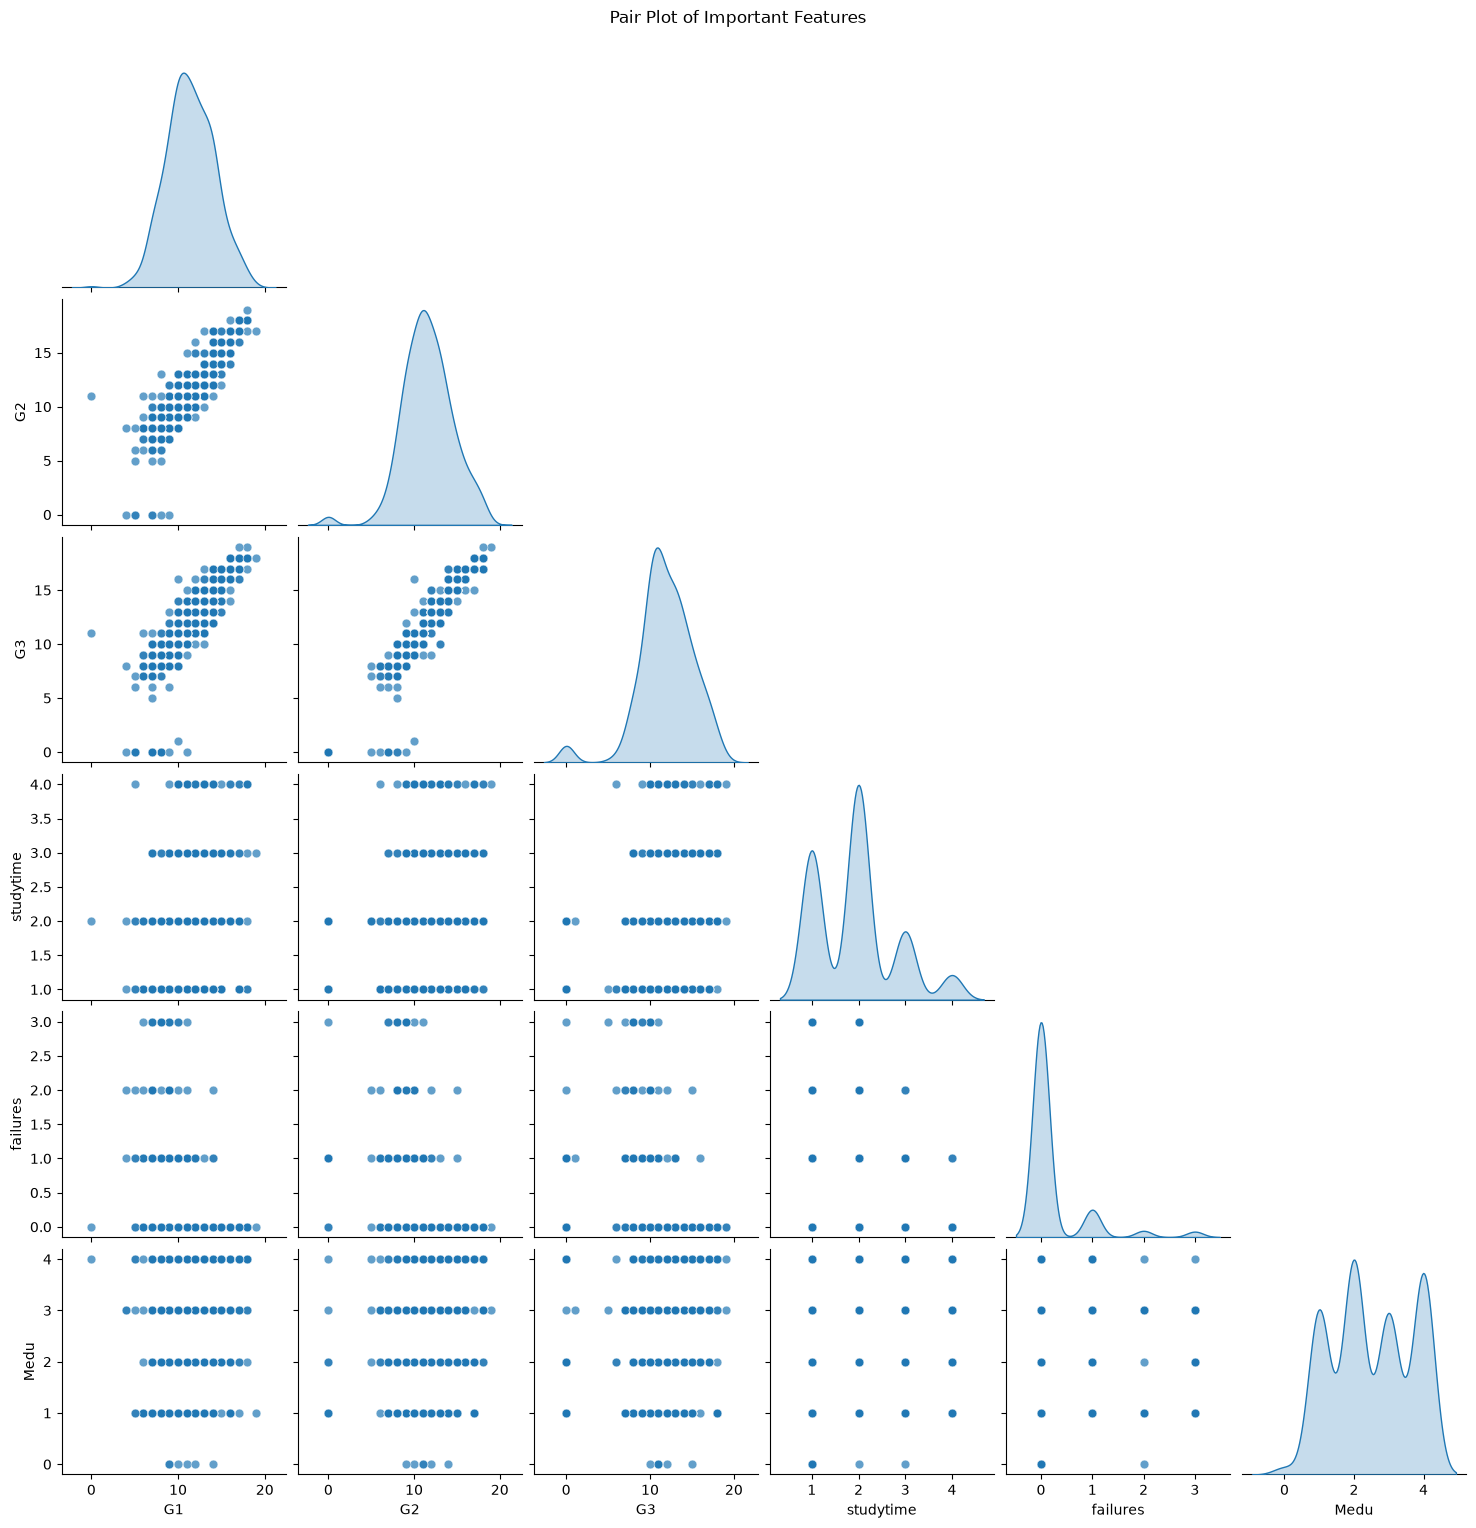

In [75]:
pair_features = ["G1","G2","G3","studytime","failures","Medu"]

sns.pairplot(df[pair_features],diag_kind="kde",corner=True,plot_kws={"alpha":0.7, "s":40})
plt.suptitle("Pair Plot of Important Features", y=1.02)

plt.show()

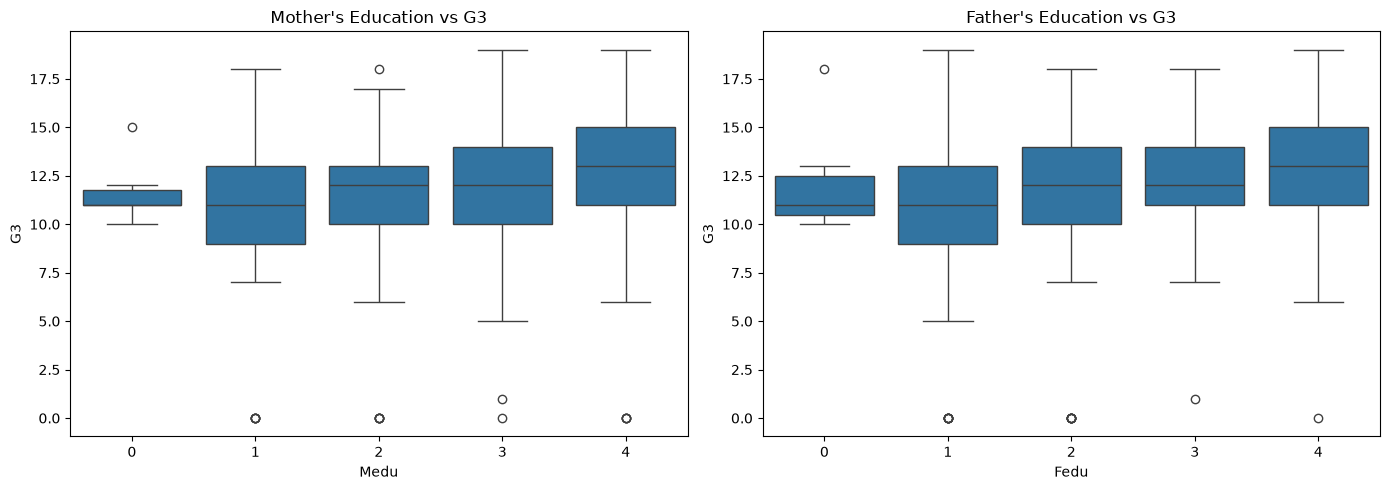

In [76]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(x="Medu", y="G3", data=df, ax=ax[0])
ax[0].set_title("Mother's Education vs G3")

sns.boxplot(x="Fedu", y="G3", data=df, ax=ax[1])
ax[1].set_title("Father's Education vs G3")

plt.tight_layout()
plt.show()

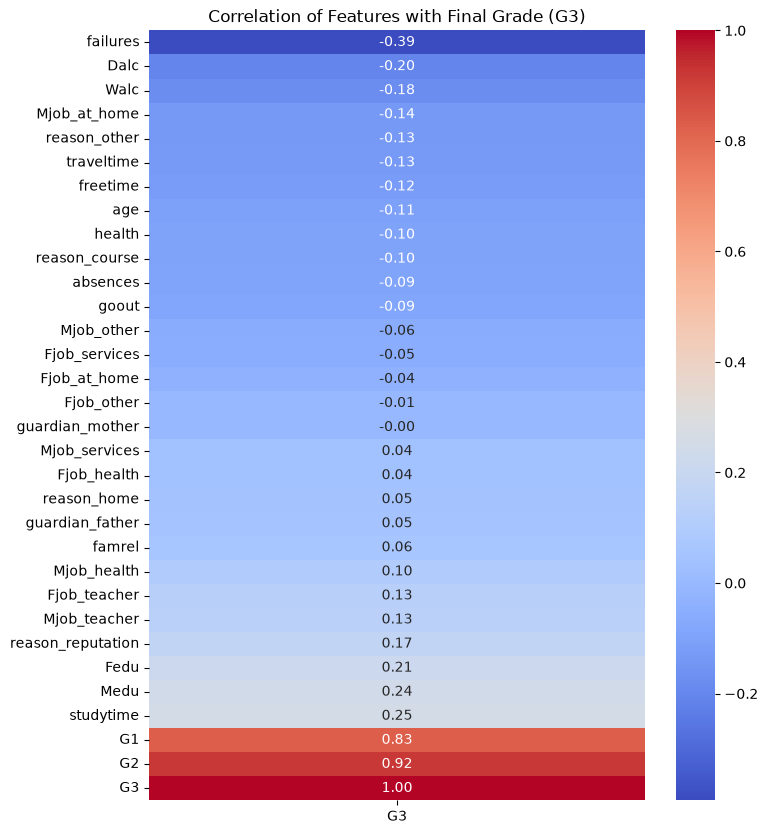

In [77]:
corr = df.corr(numeric_only=True)["G3"].sort_values()

plt.figure(figsize=(8,10))
sns.heatmap(corr.to_frame(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation of Features with Final Grade (G3)")
plt.show()

In [78]:

sns.boxplot(data=df[["G1","G2","G3","absences"]], ax=ax[1])

ax[1].set_title("Outlier Detection")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [79]:
df["parent_education"] = df["Medu"] + df["Fedu"]
df["avg_grade"] = (df["G1"] + df["G2"]) / 2
df["alcohol_consumption"] = df["Dalc"] + df["Walc"]
df["avg_grade"] = (df["G1"] + df["G2"]) / 2

In [80]:
# saving the cleaned csv into new csv file
df.to_csv('..\\datasets\\studt_perf_cleaned.csv', index= False)